In [4]:
df = pl.read_csv("data/qc_contracts_20260226_211521.csv")
mislav_tickers = df["symbol"].str.split(" ").list.first().unique().sort().to_list()

In [13]:
combined = pl.concat([decile1, decile10]) # both short and long option contracts
combined_tickers = combined["ticker"].unique().to_list()
# Tickers in mislav but NOT in decile10
missing = [t for t in mislav_tickers if t not in combined_tickers]
print(f"Missing from decile10: {missing}")
print(f"{len(mislav_tickers) - len(missing)}/{len(mislav_tickers)} found in decile10")

Missing from decile10: ['AVTR', 'EME', 'G', 'HEI', 'NTNX', 'SNOW', 'ZM']
33/40 found in decile10


---
---
---
---
---

In [ ]:
from constant_iv_term_structure_engine import constantIVTermStructureEngine
import polars as pl

tickers = open("symbols.txt").read().splitlines()
engine = constantIVTermStructureEngine(ticker=tickers, auto_sync=False)
result = engine.run()

# Filter for latest trade_date, decile 10 (same as daily_trader.py)
decile10 = result.filter(
    (pl.col("trade_date") == pl.col("trade_date").max()) &
    (pl.col("q_slope") == 10)
)

decile1 = result.filter(
    (pl.col("trade_date") == pl.col("trade_date").max()) &
    (pl.col("q_slope") == 1)
)

print(decile10.select("ticker", "cOpra_ST", "pOpra_ST", "SLOPE", "q_slope"))

In [22]:
# import nest_asyncio
# nest_asyncio.apply()

# from ib_insync import IB, MarketOrder

# ib = IB()
# ib.connect('127.0.0.1', 7497, clientId=2)

# positions = ib.positions()

# for pos in positions:
#     contract = pos.contract
#     ib.qualifyContracts(contract)  # fill in contract details
    
#     qty = pos.position
#     if qty == 0:
#         continue
    
#     # If long, sell. If short, buy to cover.
#     action = 'SELL' if qty > 0 else 'BUY'
#     order = MarketOrder(action, abs(qty))
    
#     trade = ib.placeOrder(contract, order)
#     print(f"Closing {contract.symbol} | {action} {abs(qty)} shares")

# ib.sleep(2)  # wait for fills

# # Verify
# for trade in ib.trades():
#     print(f"{trade.contract.symbol} | Status: {trade.orderStatus.status}")

# ib.disconnect()

In [24]:
len(positions)

194

In [1]:
# about 5 minutes 15 seconds
from constant_iv_term_structure_engine import constantIVTermStructureEngine

# ticker = ["AAPL", "MSFT", "GOOGL"]
# tickers = open("symbols.txt").read().splitlines()[:100] # test first 50
tickers = open("symbols.txt").read().splitlines()

engine = constantIVTermStructureEngine(ticker=tickers)
result = engine.run()

[SYNC] Syncing ORATS cache...
✓ FTP Login successful: 230 User logged in, proceed.
✓ Connected to database: data/ORATS_OPTIONS_DB.duckdb
Year 2025: 1 missing dates to download
✓ Changed to directory: /smvstrikes/2025


Syncing 2025: 100%|██████████| 1/1 [00:01<00:00,  1.80s/it]

  No new data extracted (all 1 dates were weekends/holidays)
✓ Year 2026: Already up to date (no missing dates)
✓ FTP connection closed
✓ DuckDB connection closed
[SYNC] ORATS cache is up to date.
Running 1000 tickers in parallel with 16 cores...


[TSLA] [1/11] Fetching equity data...
[GOOGL] [1/11] Fetching equity data...
[TSM] [1/11] Fetching equity data...
[AAPL] [1/11] Fetching equity data...
[AVGO] [1/11] Fetching equity data...
[INTC] [1/11] Fetching equity data...
[MU] [1/11] Fetching equity data...
[NFLX] [1/11] Fetching equity data...
[META] [1/11] Fetching equity data...
[GOOG] [1/11] Fetching equity data...
[AMD] [1/11] Fetching equity data...
[PLTR] [1/11] Fetching equity data...
[AMZN] [1/11] Fetching equity data...
[NVDA] [1/11] Fetching equity data...
[ORCL] [1/11] Fetching equity data...
[UNH] [1/11] Fetching equity data...
[META]         Equity rows: 1089
[META] [2/11] Fetching options data...
[PLTR]         Equity rows: 1367
[PLTR] [2/11] Fetching options data...
[GOOGL]         Equity rows: 3002
[GOOGL] [2/11] Fetching options data...
[UNH]         Equity rows: 5661
[UNH] [2/11] Fetching options data...
[AMD]         Equity rows: 5661
[AMD] [2/11] Fetching options data...
[AVGO]         Equity rows: 4174
[AVGO

---
---
---
---
---


In [2]:
# 2. Compute trade execution returns
next_df = engine.trade_execution(result)
next_df

ticker,expirDate,trade_date,cOpra,pOpra,cOpra_ST,pOpra_ST,straddle_price_bid,straddle_price_ask,straddle_price_mid,q_slope,next_mid,next_bid,next_ask,ret_fill_00,ret_fill_11,ret_fill_22,ret_fill_33,ret_fill_44,ret_fill_56,ret_fill_67,ret_fill_78,ret_fill_89,ret_fill_100,short_ret_fill_00,short_ret_fill_11,short_ret_fill_22,short_ret_fill_33,short_ret_fill_44,short_ret_fill_56,short_ret_fill_67,short_ret_fill_78,short_ret_fill_89,short_ret_fill_100
str,datetime[μs],date,str,str,str,str,f64,f64,f64,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""PLTR""",2026-06-18 00:00:00,2025-01-02,"""PLTR260618C00085000""","""PLTR260618P00085000""","""PLTR260618C00085000""","""PLTR260618P00085000""",45.75,48.1,46.925,1,47.8,47.15,48.45,0.018647,0.014286,0.009949,0.005636,0.001347,-0.002919,-0.007162,-0.011381,-0.015577,-0.019751,-0.018305,-0.022514,-0.026709,-0.030892,-0.035062,-0.03922,-0.043366,-0.047499,-0.051619,-0.055728
"""PLTR""",2026-06-18 00:00:00,2025-01-03,"""PLTR260618C00085000""","""PLTR260618P00085000""","""PLTR260618C00085000""","""PLTR260618P00085000""",47.15,48.45,47.8,2,47.725,46.05,49.4,-0.001569,-0.006963,-0.012341,-0.017702,-0.023048,-0.028377,-0.03369,-0.038988,-0.04427,-0.049536,0.001572,-0.003827,-0.009183,-0.014498,-0.019772,-0.025006,-0.0302,-0.035354,-0.04047,-0.045547
"""PLTR""",2026-06-18 00:00:00,2025-01-06,"""PLTR260618C00085000""","""PLTR260618P00085000""","""PLTR260618C00085000""","""PLTR260618P00085000""",46.05,49.4,47.725,1,42.175,41.65,42.7,-0.116291,-0.120942,-0.125556,-0.130135,-0.134678,-0.139187,-0.143661,-0.148102,-0.152509,-0.156883,0.131595,0.125625,0.119672,0.113735,0.107814,0.10191,0.096022,0.09015,0.084294,0.078454
"""PLTR""",2026-06-18 00:00:00,2025-01-07,"""PLTR260618C00075000""","""PLTR260618P00075000""","""PLTR260618C00075000""","""PLTR260618P00075000""",41.65,42.7,42.175,1,41.95,41.65,42.25,-0.005335,-0.007498,-0.009655,-0.011806,-0.013952,-0.016091,-0.018225,-0.020352,-0.022474,-0.02459,0.005364,0.003176,0.000992,-0.001189,-0.003366,-0.00554,-0.007711,-0.009878,-0.012041,-0.014201
"""PLTR""",2026-06-18 00:00:00,2025-01-08,"""PLTR260618C00075000""","""PLTR260618P00075000""","""PLTR260618C00075000""","""PLTR260618P00075000""",41.65,42.25,41.95,1,39.725,38.85,40.6,-0.053039,-0.056107,-0.05917,-0.062228,-0.065281,-0.068329,-0.071372,-0.074411,-0.077444,-0.080473,0.05601,0.052595,0.049196,0.045814,0.042449,0.039099,0.035766,0.032449,0.029148,0.025862
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""CMC""",2026-03-20 00:00:00,2026-03-05,"""CMC260320C00067500""","""CMC260320P00067500""","""CMC260417C00067500""","""CMC260417P00067500""",4.5,5.7,5.1,1,4.5,3.9,5.1,-0.117647,-0.141935,-0.165605,-0.188679,-0.21118,-0.233129,-0.254545,-0.275449,-0.295858,-0.315789,0.133333,0.10219,0.071942,0.042553,0.013986,-0.013793,-0.040816,-0.067114,-0.092715,-0.117647
"""CMC""",2026-03-20 00:00:00,2026-03-06,"""CMC260320C00065000""","""CMC260320P00065000""","""CMC260417C00065000""","""CMC260417P00065000""",3.9,5.1,4.5,1,4.475,3.6,5.35,-0.005556,-0.041363,-0.076139,-0.109929,-0.142774,-0.174713,-0.205782,-0.236018,-0.265453,-0.294118,0.005587,-0.030377,-0.064842,-0.097902,-0.12964,-0.160134,-0.189456,-0.217672,-0.244844,-0.271028
"""CMC""",2026-03-20 00:00:00,2026-03-09,"""CMC260320C00065000""","""CMC260320P00065000""","""CMC260417C00065000""","""CMC260417P00065000""",3.6,5.35,4.475,2,4.075,3.6,4.55,-0.089385,-0.120292,-0.149911,-0.178322,-0.205597,-0.231803,-0.257002,-0.28125,-0.304601,-0.327103,0.09816,0.060565,0.02392,-0.011811,-0.046662,-0.080666,-0.113852,-0.14625,-0.177888,-0.208791


In [7]:
import polars as pl

next_df2 = next_df.filter(
    (pl.col("trade_date") == pl.col("trade_date").max()) &
    (pl.col("q_slope").is_in([1, 10])))

long_options = next_df2.filter(pl.col("q_slope") == 10)["cOpra"].to_list() # to trade
short_options = next_df2.filter(pl.col("q_slope") == 1)["pOpra"].to_list() # to trade

---
---
---
---
---
---
---
---
---
---
---

In [12]:
first_long_options = long_options[0]

In [13]:
import re
import threading
import time
from ibapi.client import EClient
from ibapi.wrapper import EWrapper
from ibapi.contract import Contract
from ibapi.order import Order


def parse_orats_symbol(opra: str) -> dict:
    """Parse ORATS cOpra/pOpra symbol into IBKR contract fields.
    
    Format: TICKER + YYMMDD + C/P + 8-digit strike (strike * 1000)
    Example: PLTR260313C00152500 -> PLTR, 20260313, C, 152.5
    """
    # Last 15 chars = YYMMDD(6) + C/P(1) + strike(8)
    ticker = opra[:-15]
    date_str = opra[-15:-9]       # YYMMDD
    right = opra[-9]              # C or P
    strike_raw = opra[-8:]        # 8-digit strike * 1000
    
    expiry = f"20{date_str}"      # IBKR wants YYYYMMDD
    strike = int(strike_raw) / 1000.0
    
    return {
        "symbol": ticker,
        "expiry": expiry,
        "right": right,
        "strike": strike,
    }


class TradingClient(EWrapper, EClient):
    """Minimal IBKR client for placing option orders."""
    
    def __init__(self):
        EClient.__init__(self, self)
        self._next_order_id = None
        self._connected = threading.Event()
        self._order_filled = threading.Event()
        self._order_status_log = []
    
    def nextValidId(self, orderId):
        self._next_order_id = orderId
        self._connected.set()
    
    def orderStatus(self, orderId, status, filled, remaining, avgFillPrice,
                    permId, parentId, lastFillPrice, clientId, whyHeld, mktCapPrice):
        self._order_status_log.append({
            "orderId": orderId, "status": status, "filled": filled,
            "remaining": remaining, "avgFillPrice": avgFillPrice,
        })
        print(f"  Order {orderId}: {status} | filled={filled} remaining={remaining} avgPrice={avgFillPrice}")
        if status in ("Filled", "Cancelled", "Inactive"):
            self._order_filled.set()
    
    def error(self, reqId, errorCode, errorString, advancedOrderRejectJson=""):
        if errorCode not in (2104, 2106, 2158, 2119, 2176):
            print(f"  Error {errorCode}: {errorString}")


def buy_option(opra: str, quantity: int = 1, host="127.0.0.1", port=7497, client_id=2):
    """Buy an option contract on IBKR paper trading.
    
    Args:
        opra: ORATS symbol (e.g. 'PLTR260313C00152500')
        quantity: number of contracts to buy
        host: TWS host
        port: 7497 for paper TWS, 7496 for live TWS
        client_id: unique client ID (use different from scanner's client_id=1)
    """
    parsed = parse_orats_symbol(opra)
    print(f"Parsed: {parsed}")
    
    # Build IBKR option contract
    contract = Contract()
    contract.symbol = parsed["symbol"]
    contract.secType = "OPT"
    contract.exchange = "SMART"
    contract.currency = "USD"
    contract.lastTradeDateOrContractMonth = parsed["expiry"]
    contract.strike = parsed["strike"]
    contract.right = parsed["right"]
    contract.multiplier = "100"
    
    # Build market order (use LMT + lmtPrice for limit orders)
    order = Order()
    order.action = "BUY"
    order.totalQuantity = quantity
    order.orderType = "MKT"
    order.eTradeOnly = ""
    order.firmQuoteOnly = ""
    
    # Connect and place order
    client = TradingClient()
    client.connect(host, port, client_id)
    
    thread = threading.Thread(target=client.run, daemon=True)
    thread.start()
    
    client._connected.wait(timeout=10)
    if client._next_order_id is None:
        print("ERROR: Could not connect to TWS. Is it running on port 7497?")
        client.disconnect()
        return None
    
    order_id = client._next_order_id
    print(f"Placing BUY MKT order #{order_id}: {quantity}x {opra}")
    print(f"  -> {parsed['symbol']} {parsed['expiry']} {parsed['strike']} {parsed['right']}")
    client.placeOrder(order_id, contract, order)
    
    # Wait for fill (up to 30s)
    client._order_filled.wait(timeout=30)
    
    time.sleep(1)  # let final status messages arrive
    client.disconnect()
    
    return client._order_status_log

In [14]:
# Preview what will be traded
print(f"Symbol: {first_long_options}")
print(f"Parsed: {parse_orats_symbol(first_long_options)}")

Symbol: PLTR260313C00152500
Parsed: {'symbol': 'PLTR', 'expiry': '20260313', 'right': 'C', 'strike': 152.5}


In [15]:
# Execute: buy 1 contract of first_long_options on paper trading
# Make sure TWS is running and paper trading is enabled on port 7497
status = buy_option(first_long_options, quantity=1)

Parsed: {'symbol': 'PLTR', 'expiry': '20260313', 'right': 'C', 'strike': 152.5}
Placing BUY MKT order #1: 1x PLTR260313C00152500
  -> PLTR 20260313 152.5 C
  Error 10349: Order TIF was set to DAY based on order preset.
  Error 399: Order Message: BUY 1 PLTR MAR 13 '26 152.5 Call Warning: Your order will not be placed at the exchange until 2026-03-11 09:30:00 US/Eastern.
  Order 1: PreSubmitted | filled=0.0 remaining=1.0 avgPrice=0.0
  Order 1: PreSubmitted | filled=0.0 remaining=1.0 avgPrice=0.0
  Order 1: Cancelled | filled=0.0 remaining=1.0 avgPrice=0.0
  Error 202: Order Canceled - reason:


---
---
---

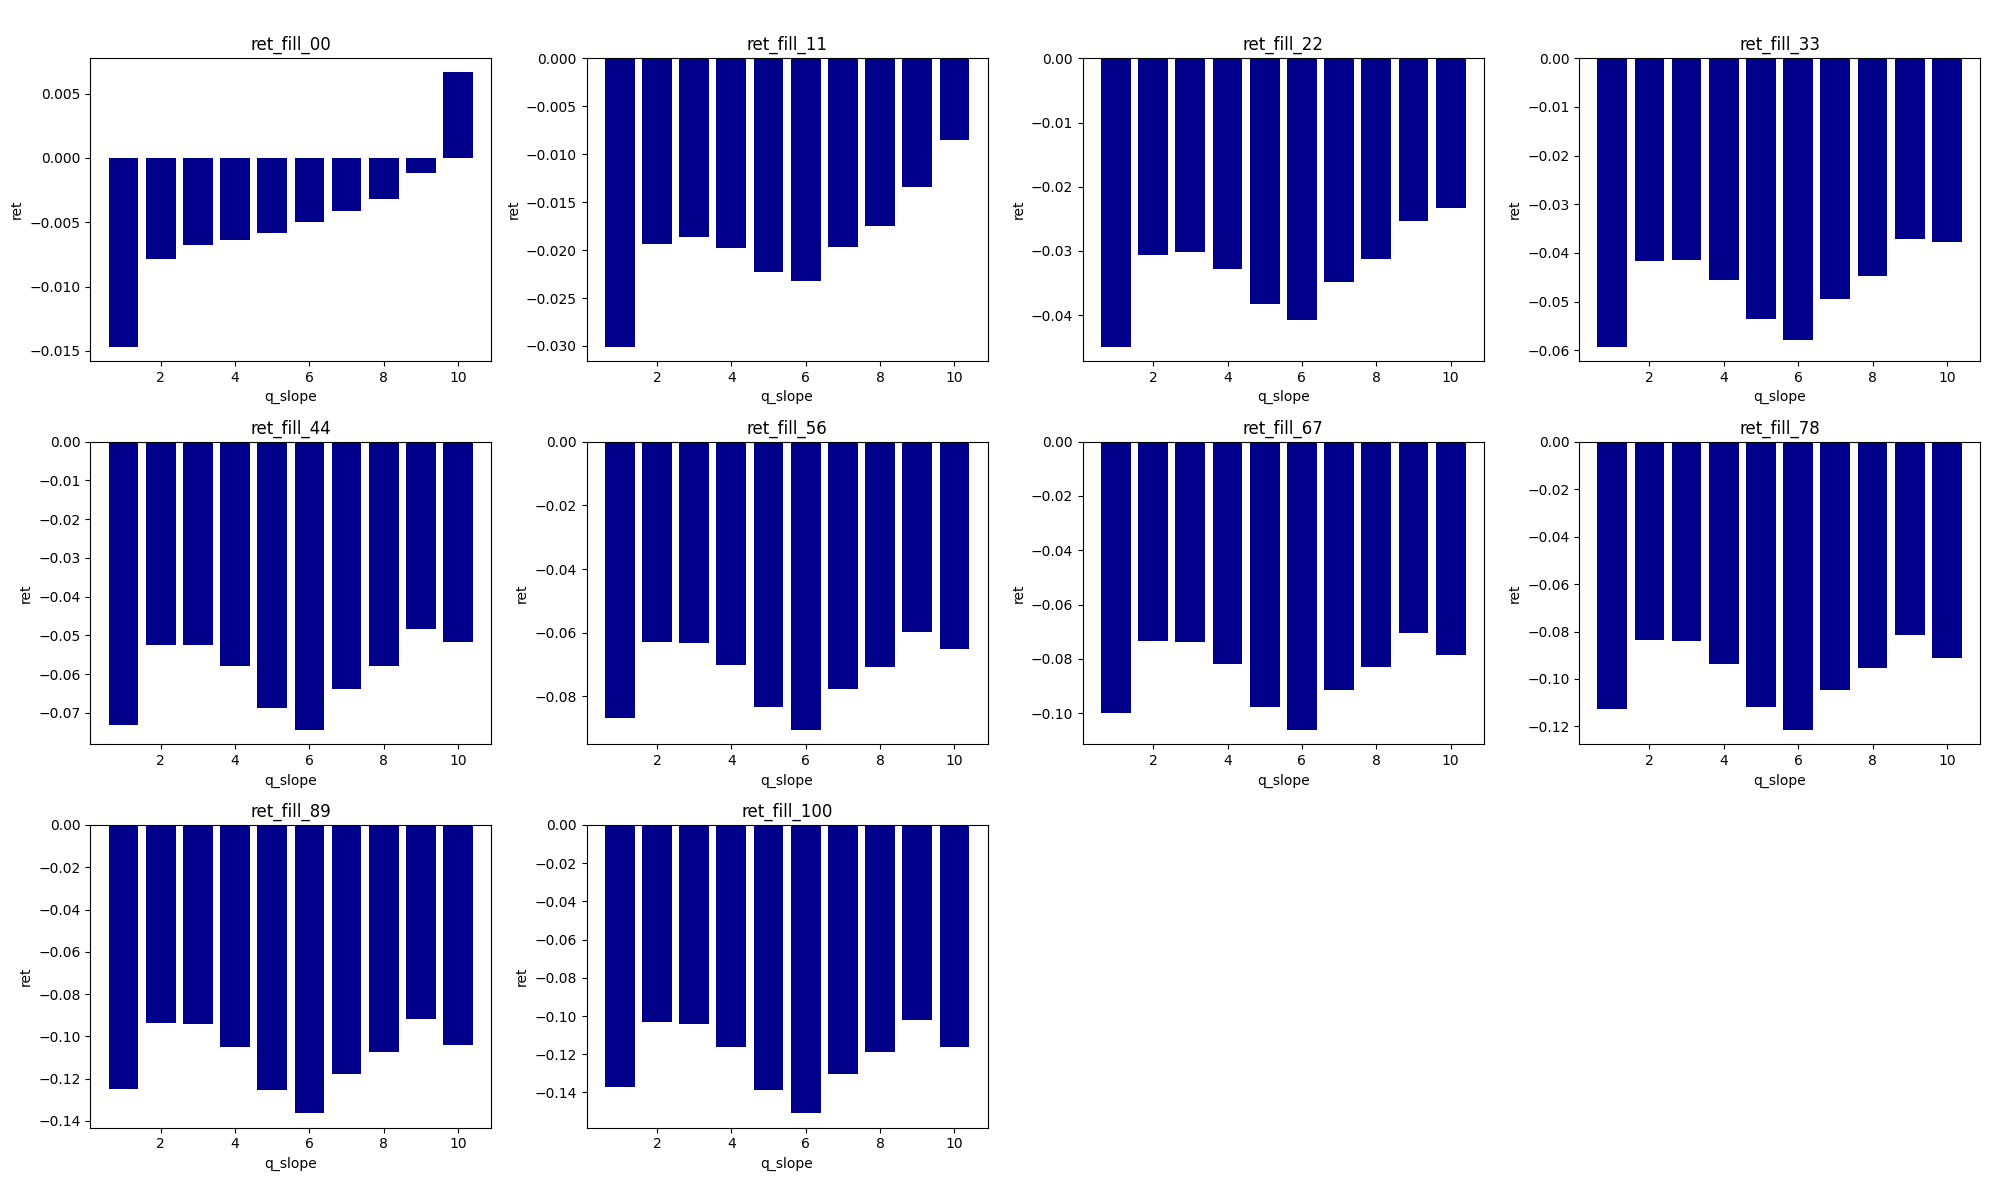

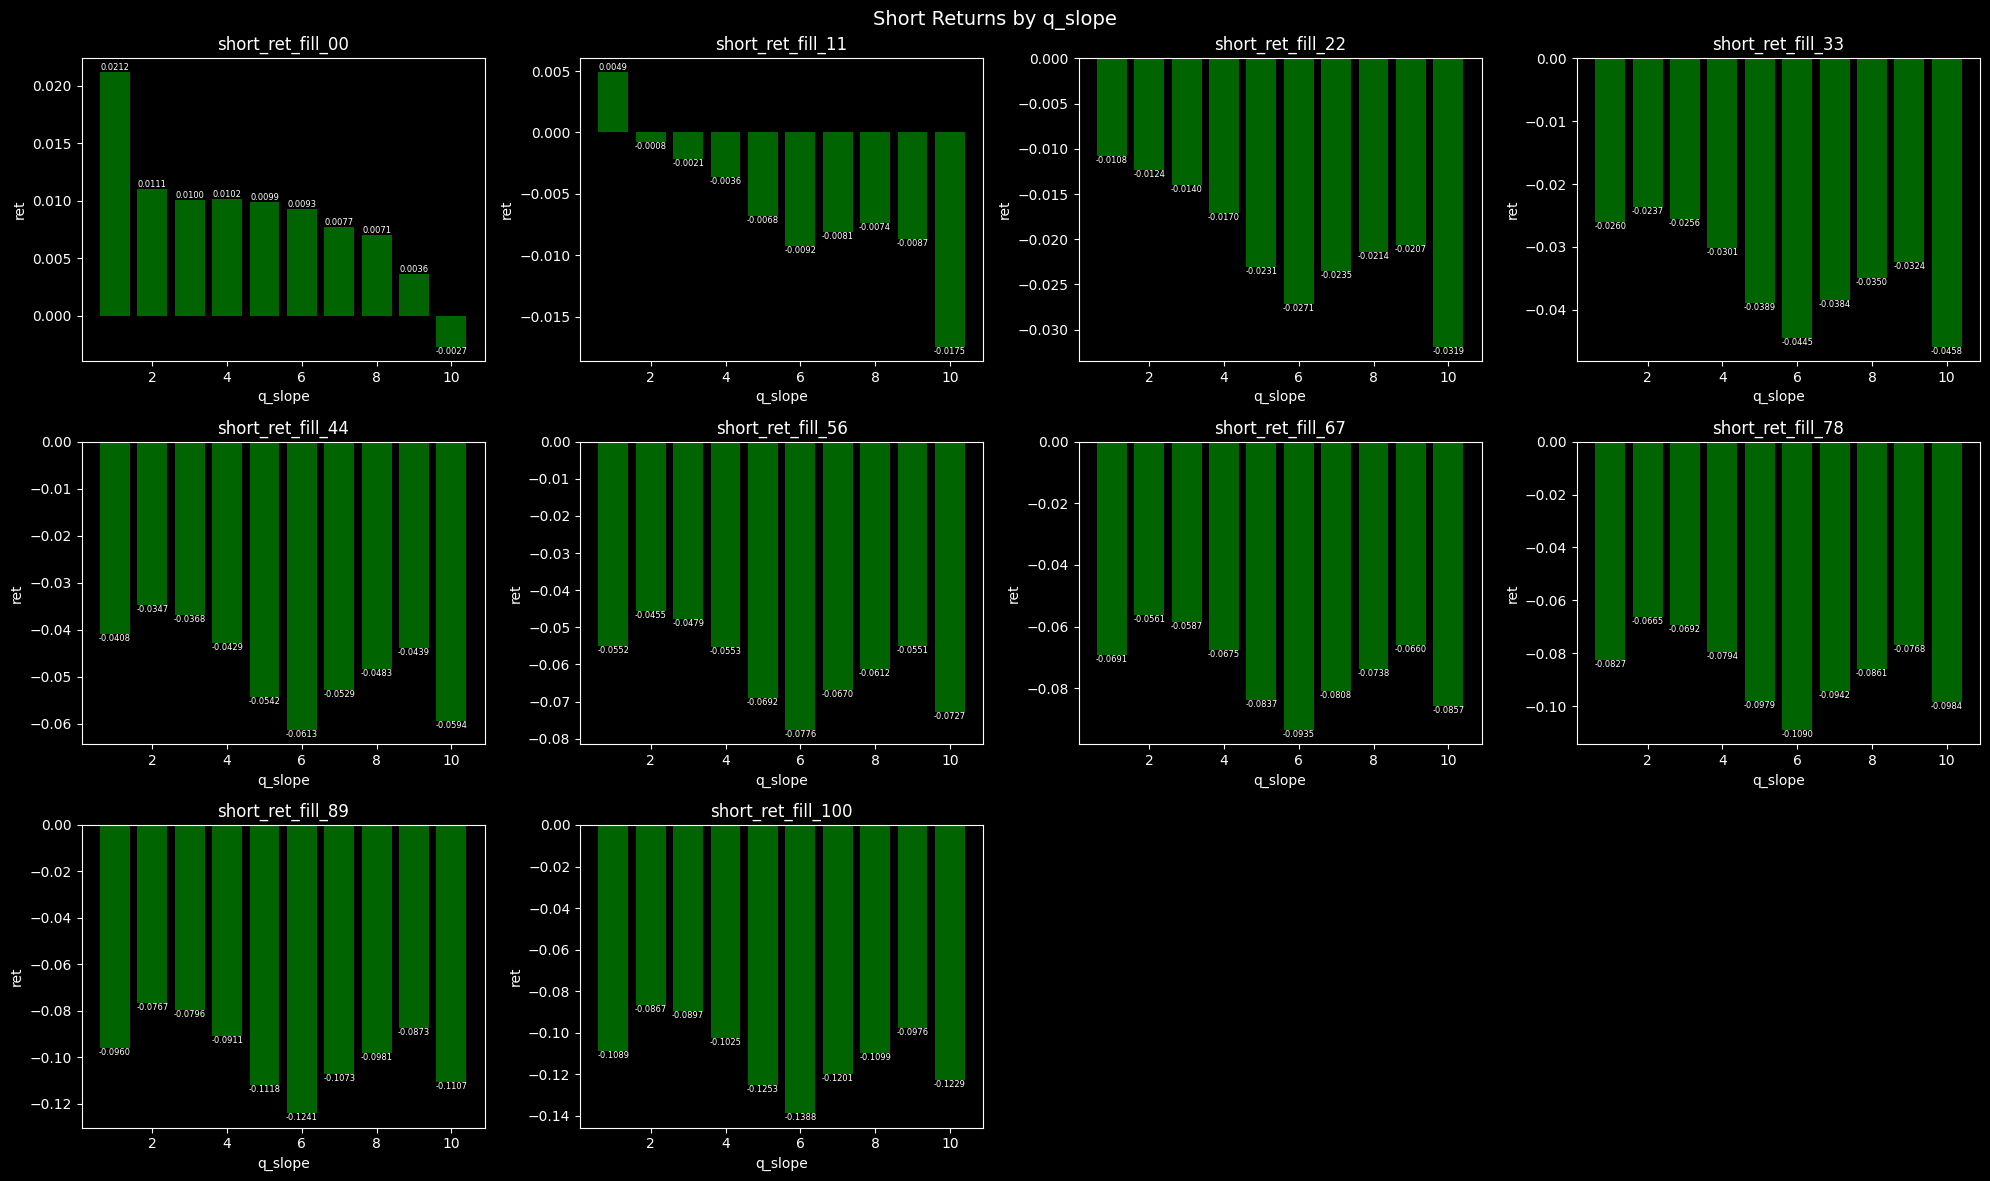

In [ ]:
# 3. Plot
engine.plot_long_returns(next_df)
engine.plot_short_returns(next_df)

---